<a href="https://colab.research.google.com/github/azkq2s/ADP-/blob/main/1_EDA1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### ADP시험 데이터에서 target이랑 feature로 나눌때

In [ ]:
import pandas as pd

df = pd.read_csv('data.csv')

# 방법 A: 컬럼 이름을 직접 알고 있을 때
target_col = 'target_column_name' # 시험 문제에 제시된 타겟 변수명
features_list = df.drop(columns=[target_col]).columns   #.drop은 새로운 객체 리턴

# 방법 B: 위치로 잡을 때 (가장 마지막 컬럼이 타겟인 경우)
X = df.iloc[:, :-1] # 마지막 열 제외 전체
y = df.iloc[:, -1]  # 마지막 열만
features_list = X.columns

*이탤릭체 텍스트* 탐색적 데이터 분석 (Exploratory Data Analysis, EDA)

탐색적 데이터 분석(EDA)은 데이터를 분석하기 전에 데이터의 특징을 파악하고 잠재적인 문제를 발견하며, 데이터에 대한 통찰력을 얻기 위한 과정입니다. EDA를 통해 데이터의 패턴, 이상치, 관계 등을 시각적으로 확인하고 통계적으로 요약하여, 모델링이나 심층 분석을 위한 기반을 다집니다.

### EDA의 주요 4가지 주제

1.  **저항성 강조 (Emphasis on Resistance)**:
    *   이상치(Outliers)에 덜 민감한 통계량 (예: 중앙값, IQR)을 사용하여 데이터의 중심 경향성과 산포도를 파악합니다.
    *   데이터의 왜곡이나 특이점이 분석 결과에 미치는 영향을 최소화하면서 견고한 통찰을 얻는 데 중점을 둡니다.

2.  **잔차 계산 (Residual Calculation)**:
    *   모델 또는 패턴에서 예측된 값과 실제 값 사이의 차이인 잔차를 계산하고 분석합니다.
    *   잔차를 통해 모델의 적합성 여부를 평가하고, 모델이 설명하지 못하는 패턴이나 시스템적인 오류를 탐지합니다.

3.  **자료변수 재표현 (Re-expression of Data Variables)**:
    *   데이터의 분포를 개선하거나 관계를 명확히 하기 위해 변수를 변환합니다 (예: 로그 변환, 제곱근 변환).
    *   이를 통해 선형성, 등분산성 등 통계적 가정을 만족시키거나 이상치의 영향을 줄이는 데 도움을 줍니다.

4.  **그래프를 통한 현시성 (Revelation Through Graphics)**:
    *   다양한 시각화 기법 (예: 히스토그램, 박스 플롯, 산점도, 잔차 플롯)을 사용하여 데이터의 숨겨진 패턴, 관계, 이상치를 시각적으로 드러냅니다.
    *   숫자 요약만으로는 발견하기 어려운 통찰을 그래프를 통해 직관적으로 파악합니다.

In [ ]:
import pandas as pd
import numpy as np

# --- 데이터 불러오기: read_csv ---
# 예시를 위해 CSV 파일을 생성하고 이를 로드합니다.
# 실제 사용 시에는 이미 존재하는 CSV 파일의 경로를 사용하시면 됩니다.

data = {
    'Name': ['Alice', 'Bob', 'Charlie', 'David', 'Eve', 'Frank', 'Grace', 'Heidi', 'Ivan', 'Judy'],
    'Age': [24, 27, 22, 32, np.nan, 29, 31, 26, 23, 30],
    'City': ['New York', 'Los Angeles', 'Chicago', 'Houston', 'Phoenix', 'New York', 'Los Angeles', 'Chicago', 'Houston', 'New York'],
    'Salary': [70000, 85000, 60000, 95000, 72000, np.nan, 80000, 65000, 78000, 90000],
    'Experience_Years': [2, 5, 1, 8, 3, 6, 4, 2, 1, 7],
    'Is_Manager': [False, True, False, True, False, False, True, False, False, True]
}

df_sample = pd.DataFrame(data)

# CSV 파일로 저장 (예시)
df_sample.to_csv('sample_data.csv', index=False)

print("Sample CSV file 'sample_data.csv' created.")

# CSV 파일 불러오기
df = pd.read_csv('sample_data.csv')
print("\nDataFrame loaded from 'sample_data.csv':")
display(df.head())

Sample CSV file 'sample_data.csv' created.

DataFrame loaded from 'sample_data.csv':


,Name,Age,City,Salary,Experience_Years,Is_Manager
0,Alice,24.0,New York,70000.0,2,False
1,Bob,27.0,Los Angeles,85000.0,5,True
2,Charlie,22.0,Chicago,60000.0,1,False
3,David,32.0,Houston,95000.0,8,True
4,Eve,NaN,Phoenix,72000.0,3,False


In [ ]:
# --- 데이터 정보 확인: info ---
print("\nDataFrame 정보 (df.info()):")
df.info()


DataFrame 정보 (df.info()):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Name              10 non-null     object 
 1   Age               9 non-null      float64
 2   City              10 non-null     object 
 3   Salary            9 non-null      float64
 4   Experience_Years  10 non-null     int64  
 5   Is_Manager        10 non-null     bool   
dtypes: bool(1), float64(2), int64(1), object(2)
memory usage: 542.0+ bytes


In [ ]:
# --- 데이터 삭제: drop ---
# 'City' 컬럼을 데이터프레임에서 제거 (원본 변경 없이)
df_without_city = df.drop(columns=['City'])
print("\n'City' 컬럼이 제거된 DataFrame (df.drop(columns=['City']) 결과):")
display(df_without_city.head())

# 'Age' 컬럼에 결측값이 있는 행 제거 (원본 변경 없이)
df_no_na_age = df.dropna(subset=['Age'])
print("\n'Age' 컬럼에 결측값이 없는 행만 남은 DataFrame (df.dropna(subset=['Age']) 결과):")
display(df_no_na_age.head())


'City' 컬럼이 제거된 DataFrame (df.drop(columns=['City']) 결과):


,Name,Age,Salary,Experience_Years,Is_Manager
0,Alice,24.0,70000.0,2,False
1,Bob,27.0,85000.0,5,True
2,Charlie,22.0,60000.0,1,False
3,David,32.0,95000.0,8,True
4,Eve,NaN,72000.0,3,False



'Age' 컬럼에 결측값이 없는 행만 남은 DataFrame (df.dropna(subset=['Age']) 결과):


,Name,Age,City,Salary,Experience_Years,Is_Manager
0,Alice,24.0,New York,70000.0,2,False
1,Bob,27.0,Los Angeles,85000.0,5,True
2,Charlie,22.0,Chicago,60000.0,1,False
3,David,32.0,Houston,95000.0,8,True
5,Frank,29.0,New York,NaN,6,False


In [ ]:
# --- 데이터 타입 변경: astype ---
# 'Is_Manager' 컬럼을 정수형 (int)으로 변경
# Boolean 값은 True=1, False=0으로 변환됩니다.

df['Is_Manager'] = df['Is_Manager'].astype(int)
print("\n'Is_Manager' 컬럼이 정수형으로 변경된 DataFrame:")
display(df.head())
print("\n변경된 'Is_Manager' 컬럼의 데이터 타입:", df['Is_Manager'].dtype)

# 'Experience_Years' 컬럼을 float로 변경 (이미 int지만 예시)
df['Experience_Years'] = df['Experience_Years'].astype(float)
print("\n'Experience_Years' 컬럼이 float으로 변경된 DataFrame:")
display(df.head())
print("\n변경된 'Experience_Years' 컬럼의 데이터 타입:", df['Experience_Years'].dtype)


'Is_Manager' 컬럼이 정수형으로 변경된 DataFrame:


,Name,Age,City,Salary,Experience_Years,Is_Manager
0,Alice,24.0,New York,70000.0,2,0
1,Bob,27.0,Los Angeles,85000.0,5,1
2,Charlie,22.0,Chicago,60000.0,1,0
3,David,32.0,Houston,95000.0,8,1
4,Eve,NaN,Phoenix,72000.0,3,0



변경된 'Is_Manager' 컬럼의 데이터 타입: int64

'Experience_Years' 컬럼이 float으로 변경된 DataFrame:


,Name,Age,City,Salary,Experience_Years,Is_Manager
0,Alice,24.0,New York,70000.0,2.0,0
1,Bob,27.0,Los Angeles,85000.0,5.0,1
2,Charlie,22.0,Chicago,60000.0,1.0,0
3,David,32.0,Houston,95000.0,8.0,1
4,Eve,NaN,Phoenix,72000.0,3.0,0



변경된 'Experience_Years' 컬럼의 데이터 타입: float64


In [ ]:
# --- 기술통계: describe ---
# 수치형 컬럼에 대한 기술통계 요약
print("\nDataFrame의 수치형 컬럼에 대한 기술통계 (df.describe()):")
display(df.describe())

# 모든 컬럼에 대한 기술통계 (범주형 포함)
print("\nDataFrame의 모든 컬럼에 대한 기술통계 (df.describe(include='all')):")
display(df.describe(include='all'))


DataFrame의 수치형 컬럼에 대한 기술통계 (df.describe()):


,Age,Salary,Experience_Years,Is_Manager
count,9.000000,9.000000,10.000000,10.000000
mean,27.111111,77222.222222,3.900000,0.400000
std,3.620927,11584.232579,2.514403,0.516398
min,22.000000,60000.000000,1.000000,0.000000
25%,24.000000,70000.000000,2.000000,0.000000
50%,27.000000,78000.000000,3.500000,0.000000
75%,30.000000,85000.000000,5.750000,1.000000
max,32.000000,95000.000000,8.000000,1.000000



DataFrame의 모든 컬럼에 대한 기술통계 (df.describe(include='all')):


,Name,Age,City,Salary,Experience_Years,Is_Manager
count,10,9.000000,10,9.000000,10.000000,10.000000
unique,10,NaN,5,NaN,NaN,NaN
top,Alice,NaN,New York,NaN,NaN,NaN
freq,1,NaN,3,NaN,NaN,NaN
mean,NaN,27.111111,NaN,77222.222222,3.900000,0.400000
std,NaN,3.620927,NaN,11584.232579,2.514403,0.516398
min,NaN,22.000000,NaN,60000.000000,1.000000,0.000000
25%,NaN,24.000000,NaN,70000.000000,2.000000,0.000000
50%,NaN,27.000000,NaN,78000.000000,3.500000,0.000000
75%,NaN,30.000000,NaN,85000.000000,5.750000,1.000000


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 'Performance_Rating' (순위형 질적 변수) 추가
performance_ratings = ['Good', 'Excellent', 'Average', 'Excellent', 'Poor', 'Good', 'Average', 'Good', 'Poor', 'Excellent']
df['Performance_Rating'] = performance_ratings

# 'Performance_Rating'을 수치형으로 인코딩 (스피어만/켄달의 타우 계산용)
# 순서가 있는 범주형 변수이므로 적절한 순서로 매핑
rating_map = {'Poor': 1, 'Average': 2, 'Good': 3, 'Excellent': 4}
df['Performance_Rating_Encoded'] = df['Performance_Rating'].map(rating_map)

print("새로운 'Performance_Rating' 컬럼이 추가된 DataFrame:")
display(df.head())

새로운 'Performance_Rating' 컬럼이 추가된 DataFrame:


,Name,Age,City,Salary,Experience_Years,Is_Manager,Performance_Rating,Performance_Rating_Encoded
0,Alice,24.0,New York,70000.0,2.0,0,Good,3
1,Bob,27.0,Los Angeles,85000.0,5.0,1,Excellent,4
2,Charlie,22.0,Chicago,60000.0,1.0,0,Average,2
3,David,32.0,Houston,95000.0,8.0,1,Excellent,4
4,Eve,NaN,Phoenix,72000.0,3.0,0,Poor,1


## 질적변수 EDA

### 1. 도수분포표 (Frequency Distribution Table)

'City' 컬럼의 각 고유값(범주)이 데이터에 몇 번 나타나는지 빈도수를 계산하여 도수분포표를 생성합니다.

In [ ]:
# 'City' 컬럼에 대한 도수분포표
frequency_table = df['City'].value_counts()
print("\n'City' 컬럼의 도수분포표:")
display(frequency_table)


'City' 컬럼의 도수분포표:


,count
City,
New York,3
Los Angeles,2
Chicago,2
Houston,2
Phoenix,1


### 2. 상대도수분포표 (Relative Frequency Distribution Table)

각 범주의 빈도수를 전체 데이터 수로 나누어 상대적인 비율을 계산한 상대도수분포표를 생성합니다. `normalize=True` 옵션을 사용합니다.

In [ ]:
# 'City' 컬럼에 대한 상대도수분포표
relative_frequency_table = df['City'].value_counts(normalize=True)
print("\n'City' 컬럼의 상대도수분포표:")
display(relative_frequency_table)


'City' 컬럼의 상대도수분포표:


,proportion
City,
New York,0.3
Los Angeles,0.2
Chicago,0.2
Houston,0.2
Phoenix,0.1


### 3. 도수분포표 시각화 (Visualization of Frequency Distribution Table)

도수분포표를 막대 그래프(Bar Plot)로 시각화하여 각 범주의 빈도를 한눈에 파악합니다. Seaborn의 `countplot`을 사용하면 편리합니다.

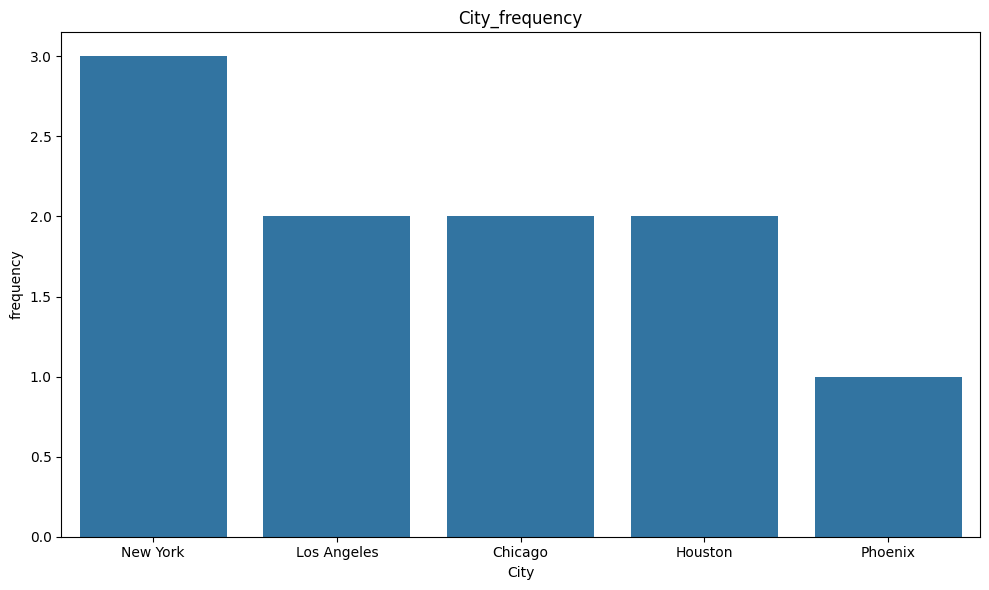

In [ ]:
# 'City' 컬럼의 도수분포표 시각화
plt.figure(figsize=(10, 6))
sns.countplot(x='City', data=df)
plt.title('City_frequency')
plt.xlabel('City')
plt.ylabel('frequency')
plt.tight_layout()
plt.show()

### 4. 스피어만 순위상관계수 (Spearman's Rank Correlation Coefficient)

스피어만 순위상관계수는 두 변수 간의 단조 관계(monotonic relationship)를 측정하는 비모수적인 통계량입니다. 주로 서열 척도(ordinal scale) 변수이거나 정규성 가정을 만족하지 않는 수량 척도(interval/ratio scale) 변수일 때 사용됩니다.

여기서는 'Experience_Years'(수량 척도, 순위화 가능)와 'Performance_Rating'(순위 척도) 간의 관계를 측정해 보겠습니다.


'Experience_Years'와 'Performance_Rating' 간의 스피어만 순위상관계수: 0.723


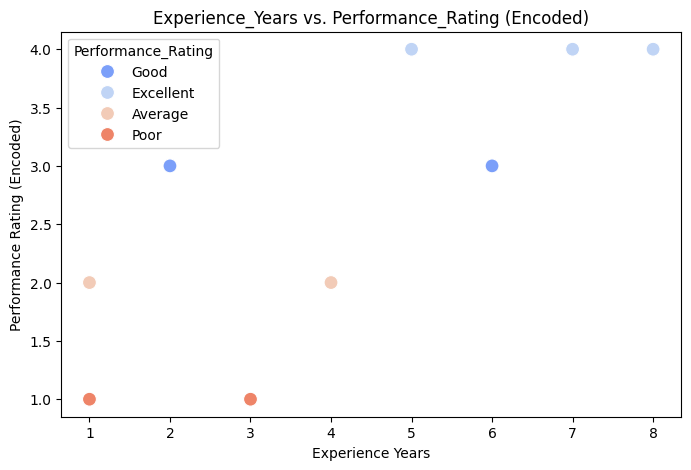

In [ ]:
# 결측값 처리 (스피어만 상관계수 계산 전)
# NaN 값이 있는 행을 제거하여 상관계수를 계산합니다.
# 'Age', 'Salary' 컬럼에 결측값이 있었으므로, 'Experience_Years'에 대한 분석 시 해당 열에 결측값이 없어야 합니다.
# 여기서는 'Experience_Years'와 'Performance_Rating_Encoded'에 결측값이 없는 데이터를 사용합니다.
df_cleaned_corr = df.dropna(subset=['Experience_Years', 'Performance_Rating_Encoded'])

# 스피어만 순위상관계수 계산
spearman_corr = df_cleaned_corr['Experience_Years'].corr(df_cleaned_corr['Performance_Rating_Encoded'], method='spearman')
print(f"\n'Experience_Years'와 'Performance_Rating' 간의 스피어만 순위상관계수: {spearman_corr:.3f}")

# 두 변수 간의 산점도 (시각화)
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Experience_Years', y='Performance_Rating_Encoded', data=df_cleaned_corr, hue='Performance_Rating', palette='coolwarm', s=100)
plt.title("Experience_Years vs. Performance_Rating (Encoded)")
plt.xlabel("Experience Years")
plt.ylabel("Performance Rating (Encoded)")
plt.show()

### 5. 켄달의 타우 (Kendall's Tau)

켄달의 타우는 스피어만 순위상관계수와 마찬가지로 두 변수 간의 순위 일치도를 측정하는 비모수적인 통계량입니다. 주로 데이터가 작거나 동률(tied ranks)이 많을 때 스피어만보다 선호될 수 있습니다.

여기서도 'Experience_Years'와 'Performance_Rating' 간의 켄달의 타우를 계산해 보겠습니다.

In [ ]:
# 켄달의 타우 상관계수 계산
kendall_corr = df_cleaned_corr['Experience_Years'].corr(df_cleaned_corr['Performance_Rating_Encoded'], method='kendall')
print(f"\n'Experience_Years'와 'Performance_Rating' 간의 켄달의 타우 상관계수: {kendall_corr:.3f}")


'Experience_Years'와 'Performance_Rating' 간의 켄달의 타우 상관계수: 0.602


## 양적변수 EDA

양적 변수(Quantitative Variable)는 수치로 측정되며, 통계적 계산이 가능한 변수입니다. 연속형(continuous) 또는 이산형(discrete)이 될 수 있습니다. 양적 변수에 대한 EDA는 주로 데이터의 분포, 중심 경향성, 산포도, 그리고 변수 간의 관계를 파악하는 데 중점을 둡니다.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gmean, skew, kurtosis

# 기존 DataFrame 'df'를 사용하되, 결측치가 있는 행을 제거하여 통계 계산을 용이하게 합니다.
# 특히 'Age'와 'Salary' 컬럼에 대한 계산을 위해 결측치를 처리합니다.
df_quantitative = df.dropna(subset=['Age', 'Salary', 'Experience_Years']).copy()

print("결측치 제거 후 양적 변수 분석용 DataFrame (df_quantitative):")
display(df_quantitative.head())

결측치 제거 후 양적 변수 분석용 DataFrame (df_quantitative):


,Name,Age,City,Salary,Experience_Years,Is_Manager,Performance_Rating,Performance_Rating_Encoded
0,Alice,24.0,New York,70000.0,2.0,0,Good,3
1,Bob,27.0,Los Angeles,85000.0,5.0,1,Excellent,4
2,Charlie,22.0,Chicago,60000.0,1.0,0,Average,2
3,David,32.0,Houston,95000.0,8.0,1,Excellent,4
6,Grace,31.0,Los Angeles,80000.0,4.0,1,Average,2


### 1. 중심 경향성 측정 (Measures of Central Tendency)

데이터의 '중심'이 어디에 위치하는지를 나타내는 지표들입니다.

In [ ]:
# 산술평균 (Arithmetic Mean)
print(f"Age의 산술평균: {df_quantitative['Age'].mean():.2f}")
print(f"Salary의 산술평균: {df_quantitative['Salary'].mean():,.2f}")

# 기하평균 (Geometric Mean) - 모든 값이 양수일 때 적합
# 'Salary'는 모두 양수이므로 기하평균을 계산합니다.
print(f"Salary의 기하평균: {gmean(df_quantitative['Salary']):,.2f}")

# 중위수 (Median)
print(f"Age의 중위수: {df_quantitative['Age'].median():.2f}")
print(f"Salary의 중위수: {df_quantitative['Salary'].median():,.2f}")

# 최빈값 (Mode) - 가장 자주 나타나는 값
# 최빈값은 여러 개일 수 있으므로 Series로 반환됩니다.
print(f"Age의 최빈값: {df_quantitative['Age'].mode().tolist()}")
print(f"City의 최빈값: {df_quantitative['City'].mode().tolist()}")

Age의 산술평균: 26.88
Salary의 산술평균: 77,875.00
Salary의 기하평균: 77,017.88
Age의 중위수: 26.50
Salary의 중위수: 79,000.00
Age의 최빈값: [22.0, 23.0, 24.0, 26.0, 27.0, 30.0, 31.0, 32.0]
City의 최빈값: ['Chicago', 'Houston', 'Los Angeles', 'New York']


### 2. 산포도 측정 (Measures of Dispersion)

데이터가 얼마나 퍼져 있는지를 나타내는 지표들입니다.

In [ ]:
# 분산 (Variance)
print(f"Age의 분산: {df_quantitative['Age'].var():.2f}")
print(f"Salary의 분산: {df_quantitative['Salary'].var():,.2f}")

# 표준편차 (Standard Deviation)
print(f"Age의 표준편차: {df_quantitative['Age'].std():.2f}")
print(f"Salary의 표준편차: {df_quantitative['Salary'].std():,.2f}")

# 변동계수 (Coefficient of Variation, CV)
# 표준편차 / 평균 * 100 (백분율)
print(f"Age의 변동계수: {df_quantitative['Age'].std() / df_quantitative['Age'].mean() * 100:.2f}%")
print(f"Salary의 변동계수: {df_quantitative['Salary'].std() / df_quantitative['Salary'].mean() * 100:.2f}%")

# 분위수, 사분위수, 백분위수 (Quantiles, Quartiles, Percentiles)
# 사분위수 (Quartiles: 25%, 50%, 75%)
print("\nAge의 사분위수:")
display(df_quantitative['Age'].quantile([0.25, 0.5, 0.75]))

# 10 분위수 (Deciles)
print("\nSalary의 10분위수:")
display(df_quantitative['Salary'].quantile(np.arange(0.1, 1.0, 0.1)))

# 90 백분위수 (90th Percentile)
print(f"Age의 90백분위수: {df_quantitative['Age'].quantile(0.90):.2f}")

Age의 분산: 14.41
Salary의 분산: 148,982,142.86
Age의 표준편차: 3.80
Salary의 표준편차: 12,205.82
Age의 변동계수: 14.13%
Salary의 변동계수: 15.67%

Age의 사분위수:


,Age
0.25,23.75
0.50,26.50
0.75,30.25



Salary의 10분위수:


,Salary
0.1,63500.0
0.2,67000.0
0.3,70800.0
0.4,76400.0
0.5,79000.0
0.6,81000.0
0.7,84500.0
0.8,88000.0
0.9,91500.0


Age의 90백분위수: 31.30


### 3. 분포의 형태 측정 (Measures of Shape of Distribution)

데이터 분포의 대칭성(왜도)과 꼬리의 두께(첨도)를 나타내는 지표들입니다.

In [ ]:
# 왜도 (Skewness)
# 양수: 오른쪽 꼬리가 김 (right-skewed)
# 음수: 왼쪽 꼬리가 김 (left-skewed)
# 0에 가까우면 대칭 분포
print(f"Age의 왜도: {df_quantitative['Age'].skew():.2f}")
print(f"Salary의 왜도: {df_quantitative['Salary'].skew():.2f}")

# 첨도 (Kurtosis)
# 양수: 꼬리가 두꺼움 (fat tails, leptokurtic)
# 음수: 꼬리가 얇음 (thin tails, platykurtic)
# 0에 가까우면 정규 분포와 비슷 (mesokurtic) - Fisher의 첨도 기준
print(f"Age의 첨도: {df_quantitative['Age'].kurt():.2f}")
print(f"Salary의 첨도: {df_quantitative['Salary'].kurt():.2f}")

Age의 왜도: 0.13
Salary의 왜도: -0.12
Age의 첨도: -1.71
Salary의 첨도: -1.14


### 4. 변수 간 관계 (Relationships Between Variables)

두 양적 변수 간의 선형적 관계의 강도와 방향을 측정합니다.


양적 변수 간 피어슨 상관계수 행렬:


,Age,Salary,Experience_Years
Age,1.000000,0.788896,0.884473
Salary,0.788896,1.000000,0.892125
Experience_Years,0.884473,0.892125,1.000000


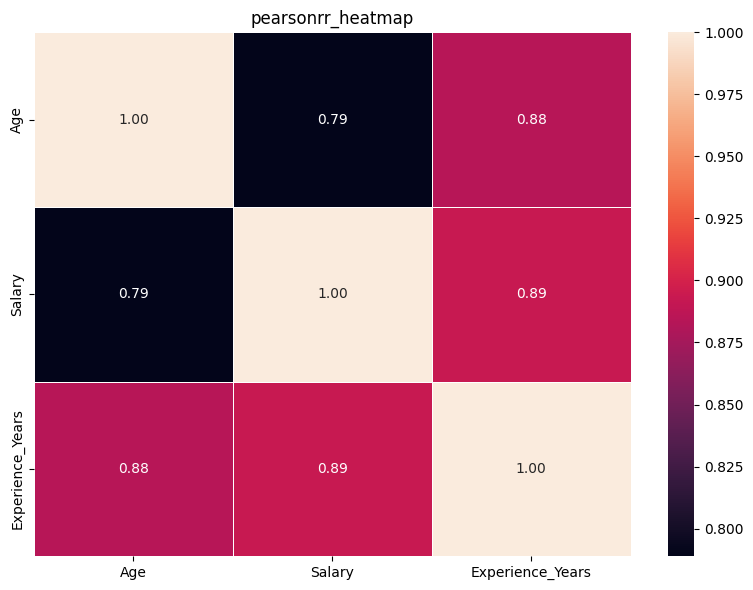

In [ ]:
# 피어슨 상관계수 (Pearson Correlation Coefficient)
# 'Age', 'Salary', 'Experience_Years' 간의 상관 행렬을 계산합니다.
print("\n양적 변수 간 피어슨 상관계수 행렬:")
display(df_quantitative[['Age', 'Salary', 'Experience_Years']].corr(method='pearson'))

# 상관 행렬 히트맵 시각화
plt.figure(figsize=(8, 6))
sns.heatmap(df_quantitative[['Age', 'Salary', 'Experience_Years']].corr(method='pearson'),
            annot=True, fmt=".2f", linewidths=.5)
plt.title('pearsonrr_heatmap')
plt.tight_layout()
plt.show()

### 5. 시각화 (Visualization)

데이터의 분포와 변수 간의 관계를 직관적으로 파악하는 데 유용한 시각화 도구들입니다.

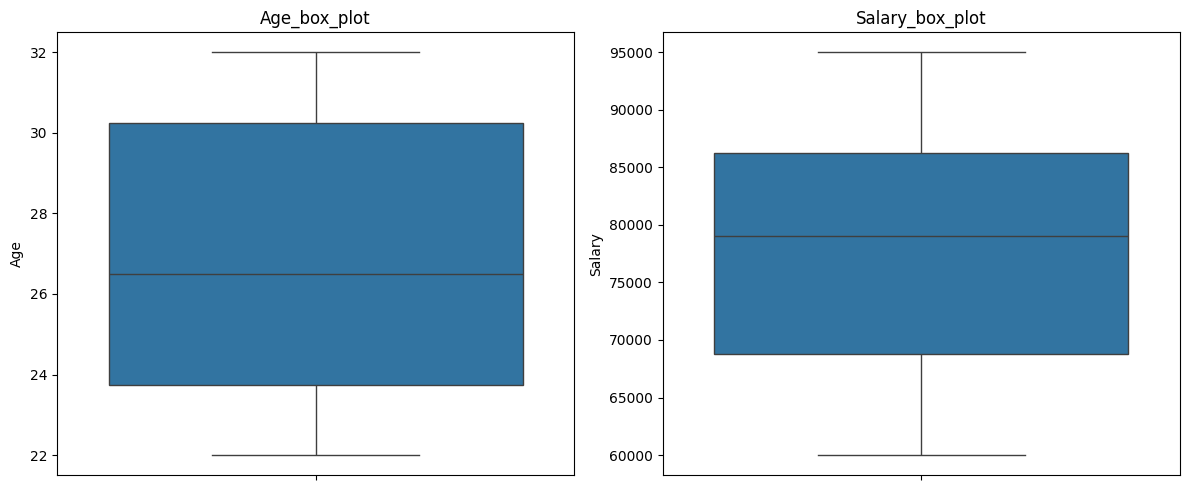

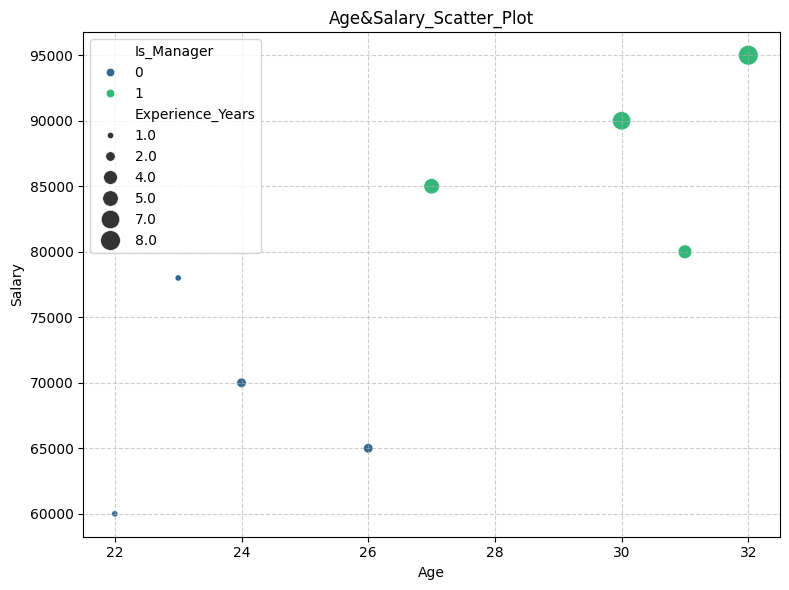

In [ ]:
# 박스플롯 (Box Plot)
# 이상치, 사분위수, 중위수 등을 한눈에 파악할 수 있습니다.
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(y=df_quantitative['Age'])
plt.title('Age_box_plot')
plt.ylabel('Age')

plt.subplot(1, 2, 2)
sns.boxplot(y=df_quantitative['Salary'])
plt.title('Salary_box_plot')
plt.ylabel('Salary')

plt.tight_layout()
plt.show()

# 스캐터플롯 (Scatter Plot)
# 두 양적 변수 간의 관계를 시각적으로 보여줍니다.
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Age', y='Salary', data=df_quantitative, hue='Is_Manager', size='Experience_Years', sizes=(20, 200), palette='viridis')
plt.title('Age&Salary_Scatter_Plot')
plt.xlabel('Age')
plt.ylabel('Salary')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()